In [1]:
from ai import MAB
import numpy as np

mab = MAB(p=[0.3, 0.5, 0.7])
stepnum = 10000
total_coin = 0
total_coins = []
mean_coin = 0
mean_coins = []
slot = {
    "total_coin": [0] * mab.num,
    "mean_coin": [0] * mab.num,
    "selectnum": [0] * mab.num,
    "total_coins": [[] for _ in range(mab.num)],
    "mean_coins": [[] for _ in range(mab.num)],
    "selectnums": [[] for _ in range(mab.num)],
}

for step in range(stepnum):
    arm = np.random.choice(mab.num)
    coin = mab.play(arm)
    total_coin += coin
    total_coins.append(total_coin)
    mean_coin = total_coin / (step + 1)
    mean_coins.append(mean_coin)
    slot["total_coin"][arm] += coin
    slot["selectnum"][arm] += 1
    slot["mean_coin"][arm] = slot["total_coin"][arm] / slot["selectnum"][arm]
    for arm in range(mab.num):
        slot["total_coins"][arm].append(slot["total_coin"][arm])
        slot["mean_coins"][arm].append(slot["mean_coin"][arm])
        slot["selectnums"][arm].append(slot["selectnum"][arm])
        
print(f"得られたコインの総数　 = {total_coin:5d}")
print(f"得られたコインの平均　 = {mean_coin:.3f}")
for arm in range(mab.num):
    print(f"スロットマシン {arm} (p={mab.p[arm]:.2f})")
    print(f"  得られたコインの総数 = {slot["total_coin"][arm]:5d}")
    print(f"  レバーを引いた回数　 = {slot["selectnum"][arm]:5d}")
    print(f"  得られたコインの平均 = {slot["mean_coin"][arm]:.3f}")

得られたコインの総数　 =  5024
得られたコインの平均　 = 0.502
スロットマシン 0 (p=0.30)
  得られたコインの総数 =  1019
  レバーを引いた回数　 =  3318
  得られたコインの平均 = 0.307
スロットマシン 1 (p=0.50)
  得られたコインの総数 =  1672
  レバーを引いた回数　 =  3371
  得られたコインの平均 = 0.496
スロットマシン 2 (p=0.70)
  得られたコインの総数 =  2333
  レバーを引いた回数　 =  3311
  得られたコインの平均 = 0.705


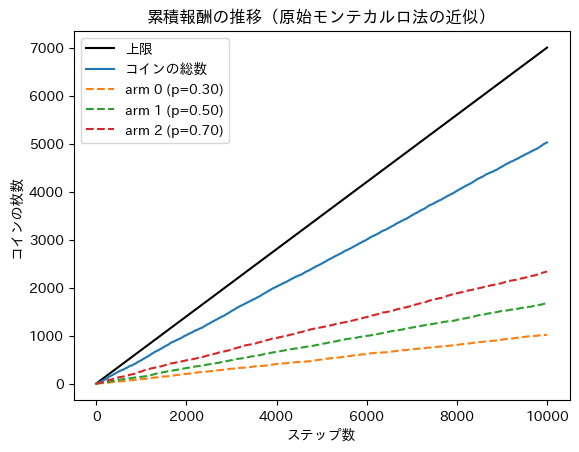

In [2]:
import matplotlib.pyplot as plt
import japanize_matplotlib

plt.title(f"累積報酬の推移（原始モンテカルロ法の近似）")
maxp = max(mab.p)
upperbounds = [step * maxp for step in range(stepnum)]
plt.plot(upperbounds, label="上限", c="k")
plt.plot(total_coins, label="コインの総数")
for arm in range(mab.num):
    plt.plot(slot["total_coins"][arm], linestyle="--", label=f"arm {arm} (p={mab.p[arm]:.2f})")
plt.xlabel("ステップ数")
plt.ylabel("コインの枚数")
plt.legend()
plt.show()

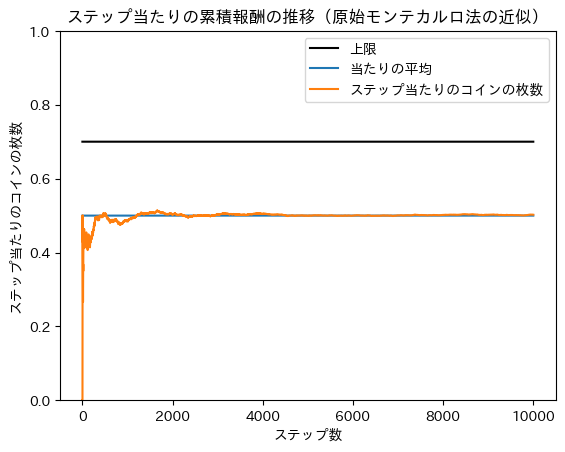

In [3]:
plt.title(f"ステップ当たりの累積報酬の推移（原始モンテカルロ法の近似）")
maxp = max(mab.p)
upperbounds = [maxp for step in range(stepnum)]
plt.plot(upperbounds, label="上限", c="k")
mean = np.mean(mab.p)
means = [mean for step in range(stepnum)]
plt.plot(means, label="当たりの平均")
plt.plot(mean_coins, label="ステップ当たりのコインの枚数")
plt.ylim(0, 1)
plt.xlabel("ステップ数")
plt.ylabel("ステップ当たりのコインの枚数")
plt.legend()
plt.show()

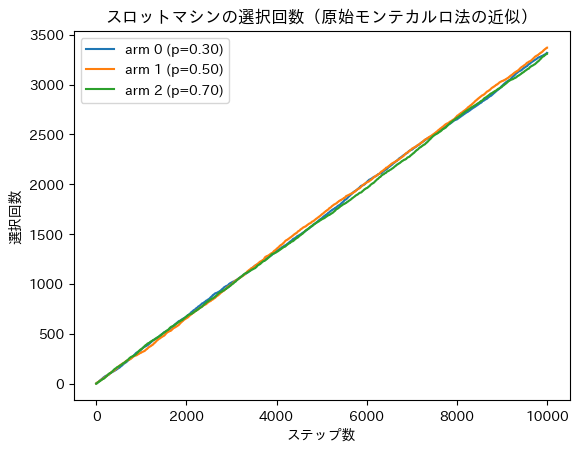

In [4]:
plt.title(f"スロットマシンの選択回数（原始モンテカルロ法の近似）")
for arm in range(mab.num):
    plt.plot(slot["selectnums"][arm], label=f"arm {arm} (p={mab.p[arm]:.2f})")
plt.xlabel("ステップ数")
plt.ylabel("選択回数")
plt.legend()
plt.show()


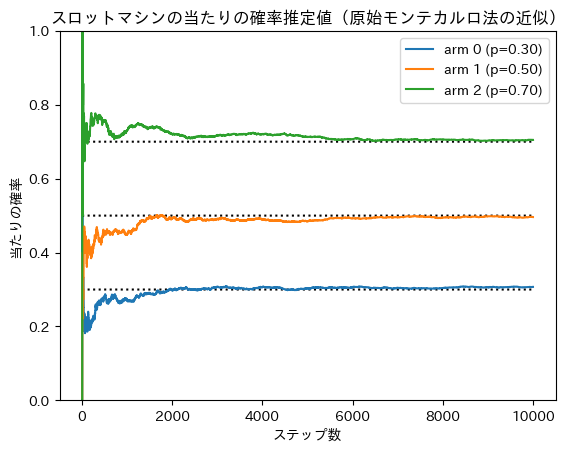

In [5]:
plt.title(f"スロットマシンの当たりの確率推定値（原始モンテカルロ法の近似）")
for arm in range(mab.num):
    plt.plot([mab.p[arm] for _ in range(stepnum)], linestyle=":", c="k")
    plt.plot(slot["mean_coins"][arm], label=f"arm {arm} (p={mab.p[arm]:.2f})")
plt.ylim(0, 1)
plt.xlabel("ステップ数")
plt.ylabel("当たりの確率")
plt.legend()
plt.show()

In [6]:
def play_episode(mab, stepnum):
    total_coin = 0
    total_coins = []
    mean_coin = 0
    mean_coins = []
    slot = {
        "total_coin": [0] * mab.num,
        "mean_coin": [0] * mab.num,
        "selectnum": [0] * mab.num,
        "total_coins": [[] for _ in range(mab.num)],
        "mean_coins": [[] for _ in range(mab.num)],
        "selectnums": [[] for _ in range(mab.num)],
    }

    for step in range(stepnum):
        arm = np.random.choice(mab.num)
        coin = mab.play(arm)
        total_coin += coin
        total_coins.append(total_coin)
        mean_coin = total_coin / (step + 1)
        mean_coins.append(mean_coin)
        slot["total_coin"][arm] += coin
        slot["selectnum"][arm] += 1
        slot["mean_coin"][arm] = slot["total_coin"][arm] / slot["selectnum"][arm]
        for arm in range(mab.num):
            slot["total_coins"][arm].append(slot["total_coin"][arm])
            slot["mean_coins"][arm].append(slot["mean_coin"][arm])
            slot["selectnums"][arm].append(slot["selectnum"][arm])
            
    return total_coin, total_coins, mean_coin, mean_coins, slot

In [7]:
total_coin, total_coins, mean_coin, mean_coins, slot = play_episode(mab, stepnum)
print(f"得られたコインの総数　 = {total_coin:5d}")
print(f"得られたコインの平均　 = {mean_coin:.3f}")
for arm in range(mab.num):
    print(f"スロットマシン {arm} (p={mab.p[arm]:.2f})")
    print(f"  得られたコインの総数 = {slot["total_coin"][arm]:5d}")
    print(f"  レバーを引いた回数　 = {slot["selectnum"][arm]:5d}")
    print(f"  得られたコインの平均 = {slot["mean_coin"][arm]:.3f}")

得られたコインの総数　 =  4967
得られたコインの平均　 = 0.497
スロットマシン 0 (p=0.30)
  得られたコインの総数 =  1013
  レバーを引いた回数　 =  3347
  得られたコインの平均 = 0.303
スロットマシン 1 (p=0.50)
  得られたコインの総数 =  1687
  レバーを引いた回数　 =  3415
  得られたコインの平均 = 0.494
スロットマシン 2 (p=0.70)
  得られたコインの総数 =  2267
  レバーを引いた回数　 =  3238
  得られたコインの平均 = 0.700


C:\Users\siges\AppData\Local\Temp\ipykernel_37232\1821022554.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


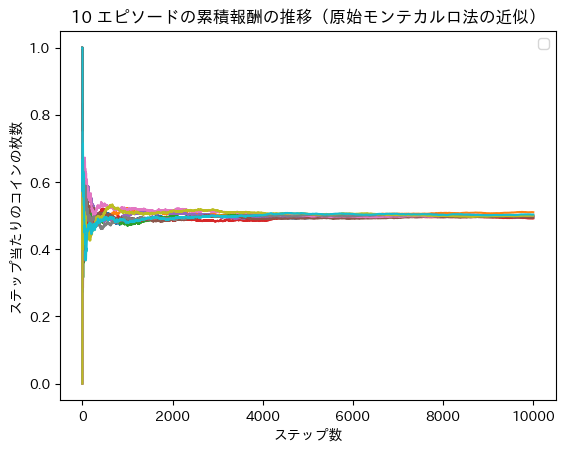

In [8]:
plt.title(f"10 エピソードの累積報酬の推移（原始モンテカルロ法の近似）")
for _ in range(10):  
    total_coin, total_coins, mean_coin, mean_coins, slot = play_episode(mab, stepnum)
    plt.plot(mean_coins)
plt.xlabel("ステップ数")
plt.ylabel("ステップ当たりのコインの枚数")
plt.legend()
plt.show()

In [9]:
episodenum = 1000
mean_coins_by_step = np.zeros((episodenum, stepnum))
slotratio_by_step = np.zeros((mab.num, episodenum, stepnum))

for episode in range(episodenum):  
    total_coin, total_coins, mean_coin, mean_coins, slot = play_episode(mab, stepnum)
    mean_coins_by_step[episode, :] = mean_coins
    for arm in range(mab.num):
        slotratio_by_step[arm, episode, :] = slot["mean_coins"][arm]

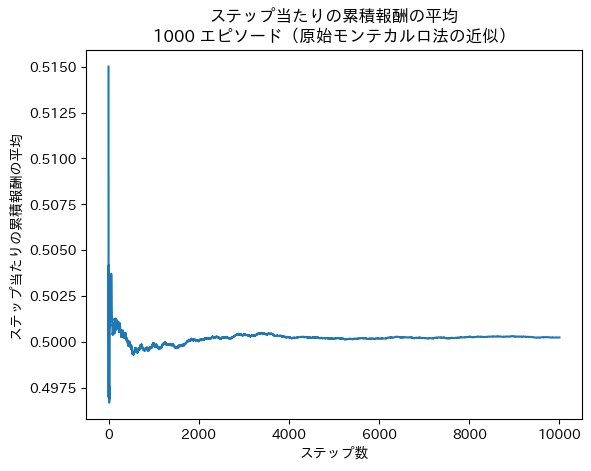

In [17]:
plt.title(f"ステップ当たりの累積報酬の平均\n{episodenum} エピソード（原始モンテカルロ法の近似）")
mean_mean_coins_by_step = np.mean(mean_coins_by_step, axis=0)
plt.plot(mean_mean_coins_by_step)
plt.xlabel("ステップ数")
plt.ylabel("ステップ当たりの累積報酬の平均")
plt.show()

最終ステップの標準偏差 = 0.00501


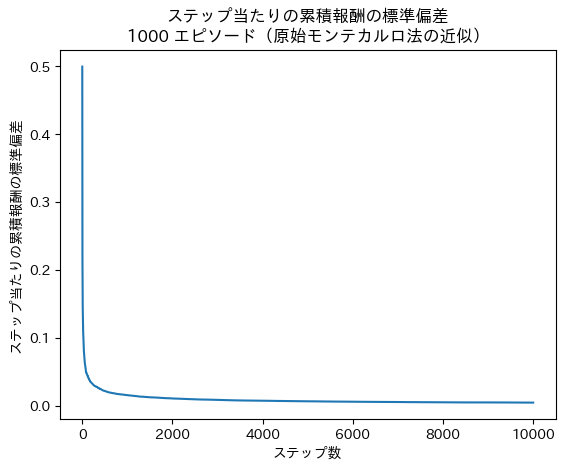

In [18]:
plt.title(f"ステップ当たりの累積報酬の標準偏差\n{episodenum} エピソード（原始モンテカルロ法の近似）")
std_mean_coins_by_step = np.std(mean_coins_by_step, axis=0)
plt.plot(std_mean_coins_by_step)
plt.xlabel("ステップ数")
plt.ylabel("ステップ当たりの累積報酬の標準偏差")
print(f"最終ステップの標準偏差 = {std_mean_coins_by_step[-1]:.5f}")

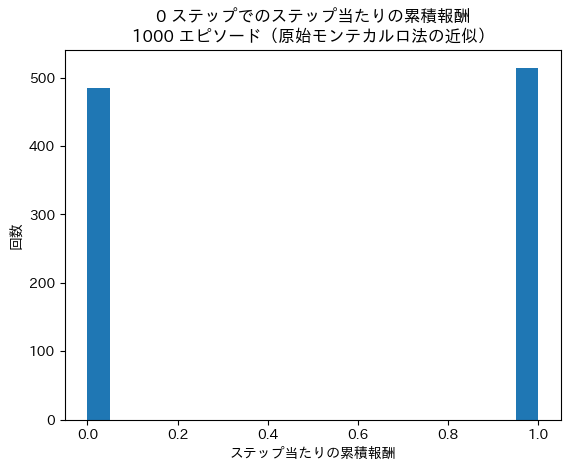

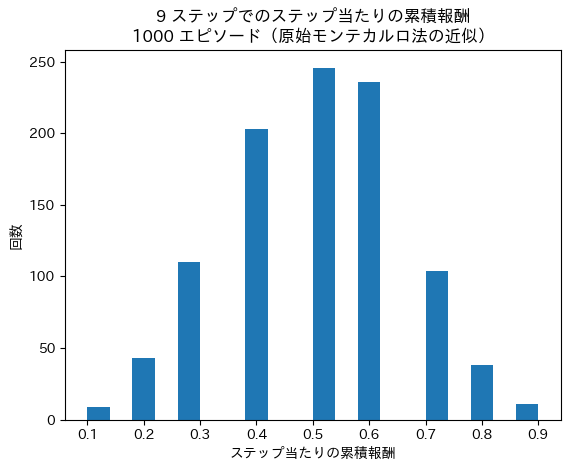

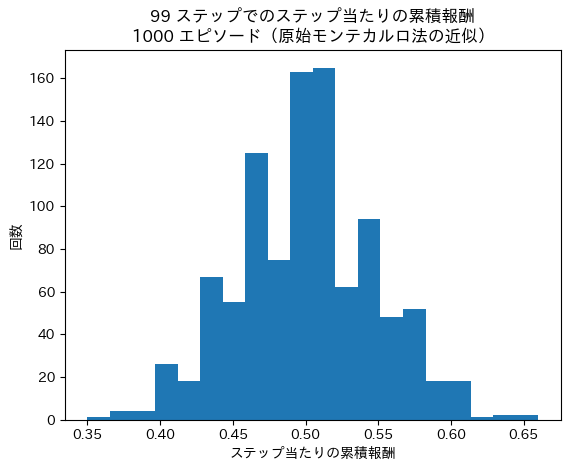

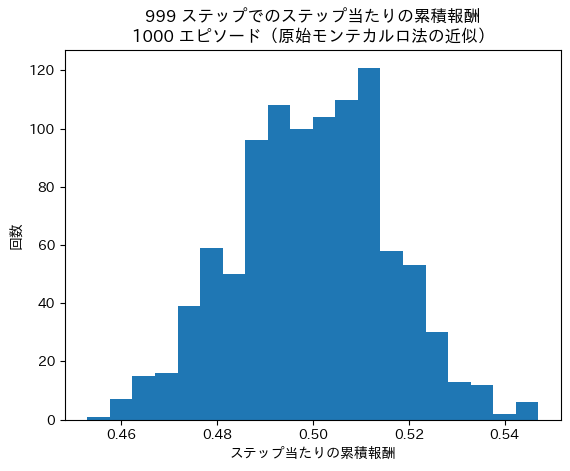

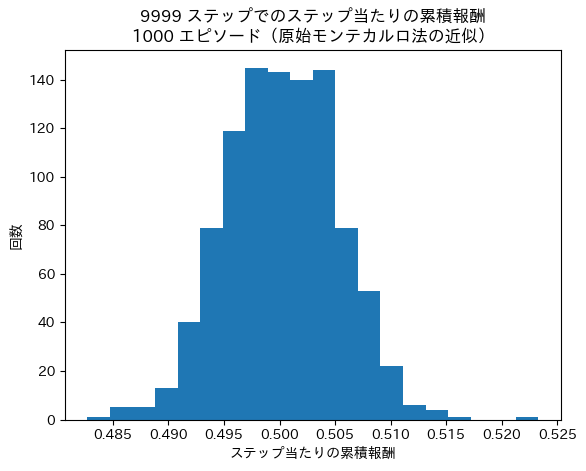

In [19]:
for step in [0, 9, 99, 999, 9999]:
    plt.title(f"{step} ステップでのステップ当たりの累積報酬\n{episodenum} エピソード（原始モンテカルロ法の近似）")
    plt.hist(mean_coins_by_step[:, step], bins=20)
    plt.xlabel("ステップ当たりの累積報酬")
    plt.ylabel("回数")
    plt.show()

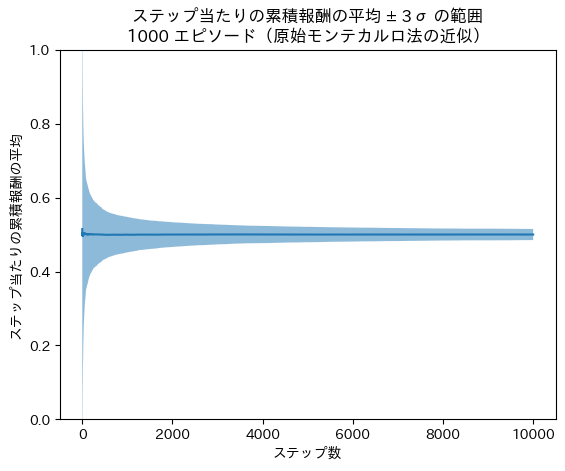

In [13]:
plt.title(f"ステップ当たりの累積報酬の平均 ± 3σ の範囲\n{episodenum} エピソード（原始モンテカルロ法の近似）")
plt.plot(mean_mean_coins_by_step)
mean_minus_3sigma =  mean_mean_coins_by_step - 3 * std_mean_coins_by_step
mean_plus_3sigma =  mean_mean_coins_by_step + 3 * std_mean_coins_by_step
plt.fill_between(np.arange(stepnum), mean_minus_3sigma, mean_plus_3sigma, alpha=0.5)
plt.ylim(0, 1)
plt.xlabel("ステップ数")
plt.ylabel("ステップ当たりの累積報酬の平均")
plt.show()

スロットマシン 0 (p=0.30)
  最終ステップの当たりの確率の推測値の平均　　 = 0.300
  最終ステップの当たりの確率の推測値の標準偏差 = 0.00796
スロットマシン 1 (p=0.50)
  最終ステップの当たりの確率の推測値の平均　　 = 0.500
  最終ステップの当たりの確率の推測値の標準偏差 = 0.00870
スロットマシン 2 (p=0.70)
  最終ステップの当たりの確率の推測値の平均　　 = 0.700
  最終ステップの当たりの確率の推測値の標準偏差 = 0.00807


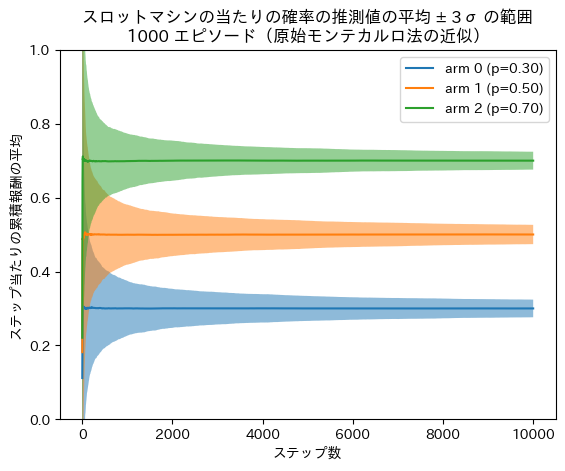

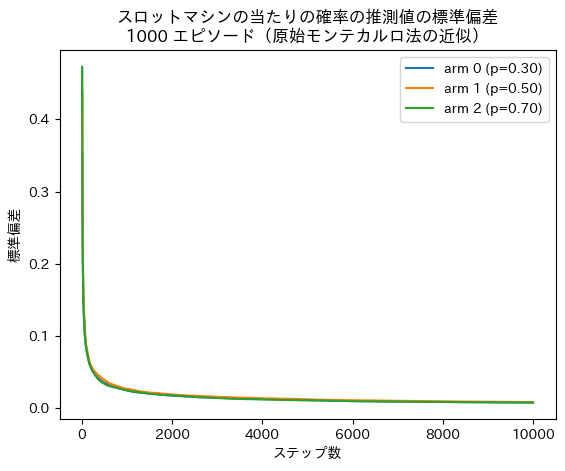

In [20]:
mean = np.mean(slotratio_by_step , axis=1) 
std = np.std(slotratio_by_step , axis=1)

plt.title(f"スロットマシンの当たりの確率の推測値の平均 ± 3σ の範囲\n{episodenum} エピソード（原始モンテカルロ法の近似）")
for arm in range(mab.num):
    plt.plot(mean[arm], label=f"arm {arm} (p={mab.p[arm]:.2f})")
    mean_minus_3sigma = mean[arm] - 3 * std[arm]
    mean_plus_3sigma = mean[arm] + 3 * std[arm]
    plt.fill_between(np.arange(stepnum), mean_minus_3sigma, mean_plus_3sigma, alpha=0.5)
    print(f"スロットマシン {arm} (p={mab.p[arm]:.2f})")
    print(f"  最終ステップの当たりの確率の推測値の平均　　 = {mean[arm][-1]:.3f}")
    print(f"  最終ステップの当たりの確率の推測値の標準偏差 = {std[arm][-1]:.5f}")

plt.ylim(0, 1)
plt.xlabel("ステップ数")
plt.ylabel("ステップ当たりの累積報酬の平均")
plt.legend()
plt.show()

plt.title(f"スロットマシンの当たりの確率の推測値の標準偏差\n{episodenum} エピソード（原始モンテカルロ法の近似）")
for arm in range(mab.num):
    plt.plot(std[arm], label=f"arm {arm} (p={mab.p[arm]:.2f})")
plt.xlabel("ステップ数")
plt.ylabel("標準偏差")
plt.legend()
plt.show()